# Analyse Exploratoire du Dataset Enrichi

Ce notebook sert uniquement a analyser les donnees presentes dans `dataset_stock_hopital_ENRICHI.csv`, sans entrainement de modele.

## Objectifs
- charger et verifier le dataset
- comprendre sa structure et sa qualite
- explorer les produits, operations et volumes
- analyser la couverture temporelle et les patterns journaliers
- examiner les variables contextuelles et les regressseurs

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='deep')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATASET_PATH = PROJECT_ROOT / 'data' / 'dataset_stock_hopital_ENRICHI.csv'

In [35]:
df = pd.read_csv(DATASET_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
if 'date_expiration' in df.columns:
    df['date_expiration'] = pd.to_datetime(df['date_expiration'], errors='coerce')

print(f'Lignes   : {len(df):,}')
print(f'Colonnes : {len(df.columns)}')
display(df.head())

Lignes   : 85,809
Colonnes : 22


,date,id_produit,nom_produit,type_produit,type_operation,type_sortie,quantite,unite,id_lot,id_arrivage,id_fournisseur,nom_fournisseur,date_expiration,stock_theorique,temperature_stockage,temperature,taux_occupation,nb_patients,epidemie_grippe,vacances_scolaires,jour_ferie,covid_impact
0,2020-01-01,1,Poulet frais,Aliment,ENTREE,NaN,30.0,kg,1,1,1,Volailles Dupont,2020-01-03,30.0,2.2,16.5,89.3,223,0,0,1,0
1,2020-01-01,2,Poisson blanc,Aliment,ENTREE,NaN,20.0,kg,2,2,8,Poissonnerie Martin,2020-01-03,20.0,3.5,16.5,89.3,223,0,0,1,0
2,2020-01-01,3,Pain frais,Aliment,ENTREE,NaN,40.0,kg,3,3,3,Boulangerie Moderne,2020-01-02,40.0,6.4,16.5,89.3,223,0,0,1,0
3,2020-01-01,4,Salade verte,Aliment,ENTREE,NaN,25.0,kg,4,4,19,Maraîcher Local,2020-01-03,25.0,5.5,16.5,89.3,223,0,0,1,0
4,2020-01-01,6,Viande hachée,Aliment,ENTREE,NaN,24.0,kg,5,5,13,Boucherie Centrale,2020-01-03,24.0,2.2,16.5,89.3,223,0,0,1,0


## 1. Structure et qualite des donnees

In [36]:
resume = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])

display(resume)

print('Doublons complets :', int(df.duplicated().sum()))
print('Dates nulles      :', int(df['date'].isna().sum()))

,dtype,missing_count,missing_pct,n_unique
type_sortie,object,13972,16.28,2
temperature_stockage,float64,9270,10.80,61
stock_theorique,float64,0,0.00,49443
quantite,float64,0,0.00,15230
id_lot,int64,0,0.00,13972
id_arrivage,int64,0,0.00,13972
date_expiration,datetime64[ns],0,0.00,2085
date,datetime64[ns],0,0.00,1827
taux_occupation,float64,0,0.00,414
temperature,float64,0,0.00,312


Doublons complets : 0
Dates nulles      : 0


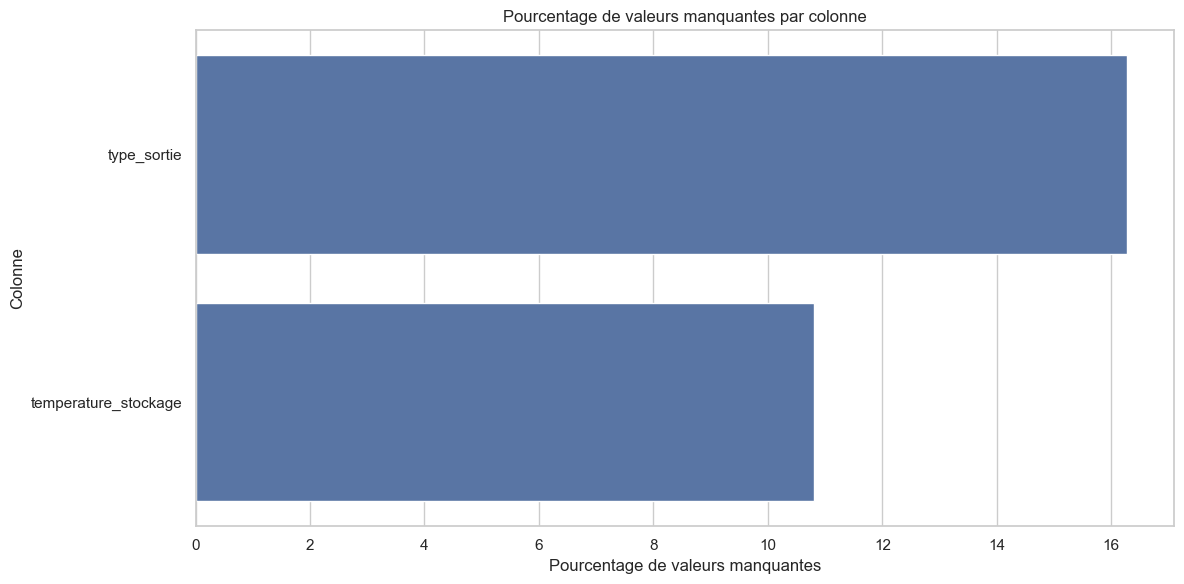

In [37]:
plt.figure(figsize=(12, 6))
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print('Aucune valeur manquante detectee.')
else:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, orient='h')
    plt.title('Pourcentage de valeurs manquantes par colonne')
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.ylabel('Colonne')
    plt.tight_layout()
    plt.show()

## 2. Couverture temporelle

,valeur
date_min,2020-01-01 00:00:00
date_max,2024-12-31 00:00:00
nb_jours_couverts,1827
nb_dates_observees,1827


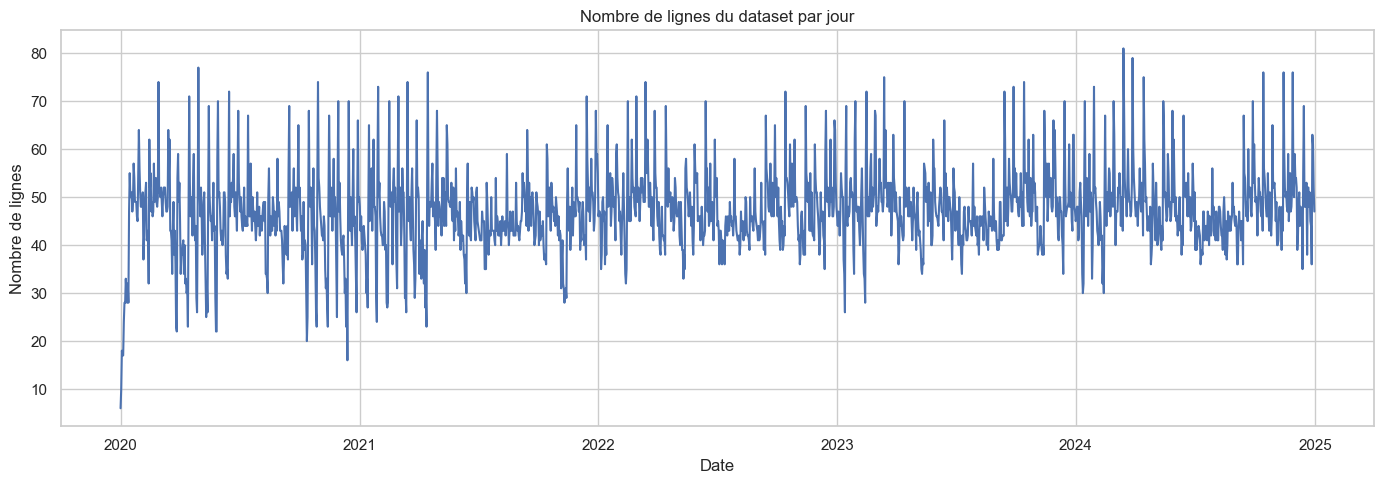

In [38]:
date_summary = {
    'date_min': df['date'].min(),
    'date_max': df['date'].max(),
    'nb_jours_couverts': (df['date'].max() - df['date'].min()).days + 1,
    'nb_dates_observees': df['date'].nunique()
}

display(pd.Series(date_summary, name='valeur').to_frame())

daily_rows = df.groupby('date').size().rename('nb_lignes').reset_index()
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_rows, x='date', y='nb_lignes')
plt.title('Nombre de lignes du dataset par jour')
plt.xlabel('Date')
plt.ylabel('Nombre de lignes')
plt.tight_layout()
plt.show()

,date,quantite,annee,mois
55,2024-08-01,20915.82,2024,8
56,2024-09-01,31575.25,2024,9
57,2024-10-01,31877.42,2024,10
58,2024-11-01,30884.51,2024,11
59,2024-12-01,35106.24,2024,12


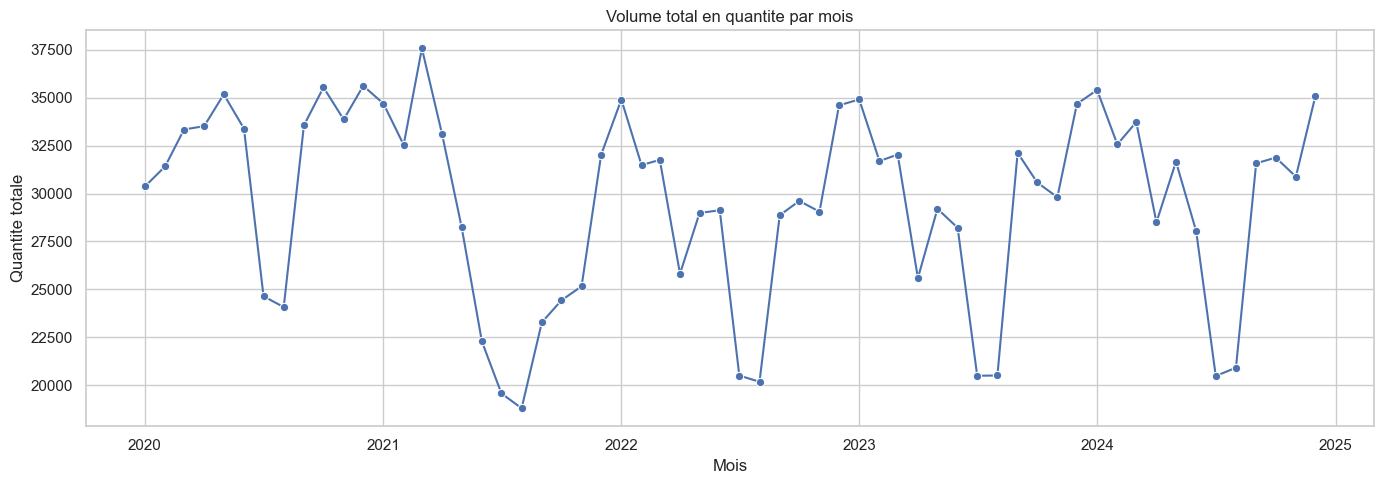

In [39]:
volume_mensuel = df.groupby(df['date'].dt.to_period('M'))['quantite'].sum().reset_index()
volume_mensuel['date'] = volume_mensuel['date'].dt.to_timestamp()
volume_mensuel['annee'] = volume_mensuel['date'].dt.year
volume_mensuel['mois'] = volume_mensuel['date'].dt.month

display(volume_mensuel.tail())

plt.figure(figsize=(14, 5))
sns.lineplot(data=volume_mensuel, x='date', y='quantite', marker='o')
plt.title('Volume total en quantite par mois')
plt.xlabel('Mois')
plt.ylabel('Quantite totale')
plt.tight_layout()
plt.show()

## 3. Produits, categories et operations

In [40]:
print('Nombre de produits uniques :', df['nom_produit'].nunique())
print('Nombre de categories       :', df['type_produit'].nunique())
print('Nombre de fournisseurs     :', df['nom_fournisseur'].nunique())

display(df['type_operation'].value_counts(dropna=False).to_frame('count'))
if 'type_sortie' in df.columns:
    display(df['type_sortie'].value_counts(dropna=False).to_frame('count'))

Nombre de produits uniques : 40
Nombre de categories       : 2
Nombre de fournisseurs     : 13


,count
type_operation,
SORTIE,71837
ENTREE,13972


,count
type_sortie,
CONSOMMATION,62576
NaN,13972
DESTRUCTION,9261


,nb_lignes,quantite_totale
nom_produit,,
Oeufs,1927,219239.95
Papier toilette,1824,143683.08
Pain frais,3625,108450.48
Lait entier,2481,104107.29
Sacs poubelle,1753,98605.64
Légumes frais,1639,90628.97
Fruits frais,1696,75157.82
Poulet frais,3734,55672.26
Poisson blanc,3320,51518.36


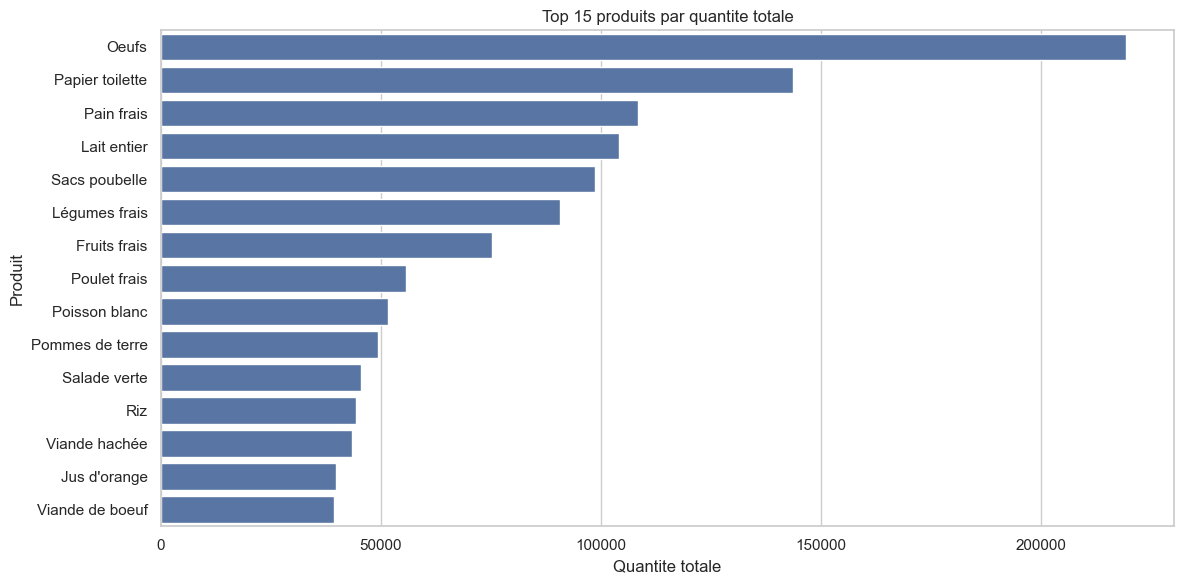

In [41]:
top_products = (
    df.groupby('nom_produit')
      .agg(nb_lignes=('nom_produit', 'size'), quantite_totale=('quantite', 'sum'))
      .sort_values('quantite_totale', ascending=False)
      .head(15)
)
display(top_products)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products.reset_index(), x='quantite_totale', y='nom_produit')
plt.title('Top 15 produits par quantite totale')
plt.xlabel('Quantite totale')
plt.ylabel('Produit')
plt.tight_layout()
plt.show()

,nb_lignes,quantite_totale
type_produit,,
Aliment,76539,1472190.44
Entretien,9270,299536.77


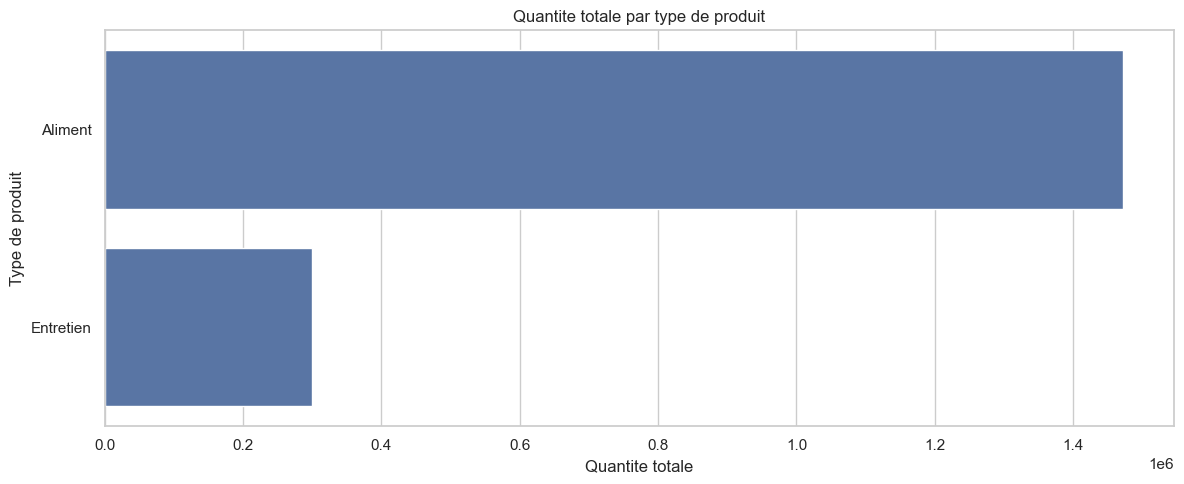

In [42]:
category_summary = (
    df.groupby('type_produit')
      .agg(nb_lignes=('type_produit', 'size'), quantite_totale=('quantite', 'sum'))
      .sort_values('quantite_totale', ascending=False)
)
display(category_summary)

plt.figure(figsize=(12, 5))
sns.barplot(data=category_summary.reset_index(), x='quantite_totale', y='type_produit')
plt.title('Quantite totale par type de produit')
plt.xlabel('Quantite totale')
plt.ylabel('Type de produit')
plt.tight_layout()
plt.show()

## 4. Focus consommation, entrees et destructions

count        sum   mean  median
type_operation type_sortie                                  
ENTREE         NaN           13972  887599.70  63.53   30.00
SORTIE         CONSOMMATION  62576  733165.40  11.72    7.13
               DESTRUCTION    9261  150962.11  16.30   14.03

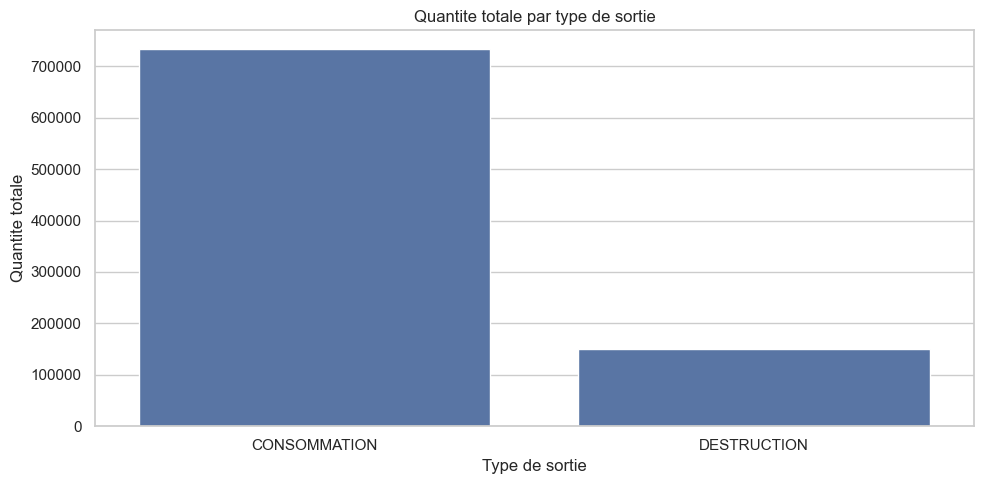

In [43]:
operation_summary = (
    df.groupby(['type_operation', 'type_sortie'], dropna=False)['quantite']
      .agg(['count', 'sum', 'mean', 'median'])
      .round(2)
)
display(operation_summary)

sorties = df[df['type_operation'].eq('SORTIE')].copy() if 'type_operation' in df.columns else df.copy()
if 'type_sortie' in sorties.columns:
    plt.figure(figsize=(10, 5))
    sortie_totals = sorties.groupby('type_sortie')['quantite'].sum().sort_values(ascending=False).reset_index()
    sns.barplot(data=sortie_totals, x='type_sortie', y='quantite')
    plt.title('Quantite totale par type de sortie')
    plt.xlabel('Type de sortie')
    plt.ylabel('Quantite totale')
    plt.tight_layout()
    plt.show()

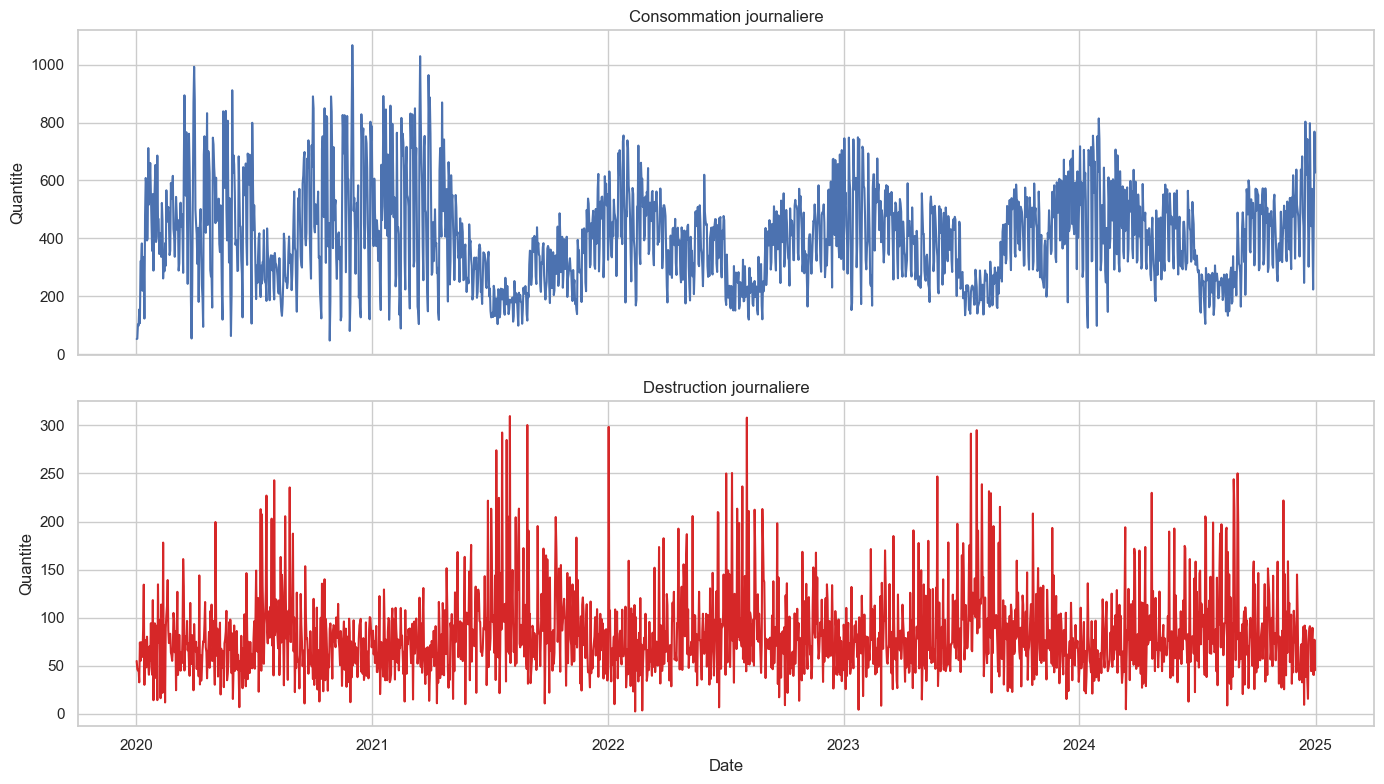

In [44]:
consumption_daily = df[df['type_sortie'].eq('CONSOMMATION')].groupby('date')['quantite'].sum().rename('quantite').reset_index()
destruction_daily = df[df['type_sortie'].eq('DESTRUCTION')].groupby('date')['quantite'].sum().rename('quantite').reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=consumption_daily, x='date', y='quantite', ax=axes[0])
axes[0].set_title('Consommation journaliere')
axes[0].set_ylabel('Quantite')

sns.lineplot(data=destruction_daily, x='date', y='quantite', ax=axes[1], color='tab:red')
axes[1].set_title('Destruction journaliere')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Quantite')

plt.tight_layout()
plt.show()

## 5. Variables contextuelles et regressseurs

In [45]:
regressor_cols = [
    'temperature',
    'taux_occupation',
    'nb_patients',
    'epidemie_grippe',
    'vacances_scolaires',
    'jour_ferie',
    'covid_impact'
]
regressor_summary = df[regressor_cols].describe().T.round(2)
display(regressor_summary)

,count,mean,std,min,25%,50%,75%,max
temperature,85809.0,14.96,7.75,-5.3,8.3,14.7,21.5,35.4
taux_occupation,85809.0,77.05,9.62,50.9,70.6,76.1,83.7,100.0
nb_patients,85809.0,191.56,24.62,128.0,174.0,189.0,209.0,258.0
epidemie_grippe,85809.0,0.10,0.30,0.0,0.0,0.0,0.0,1.0
vacances_scolaires,85809.0,0.25,0.43,0.0,0.0,0.0,0.0,1.0
jour_ferie,85809.0,0.02,0.14,0.0,0.0,0.0,0.0,1.0
covid_impact,85809.0,0.12,0.32,0.0,0.0,0.0,0.0,1.0


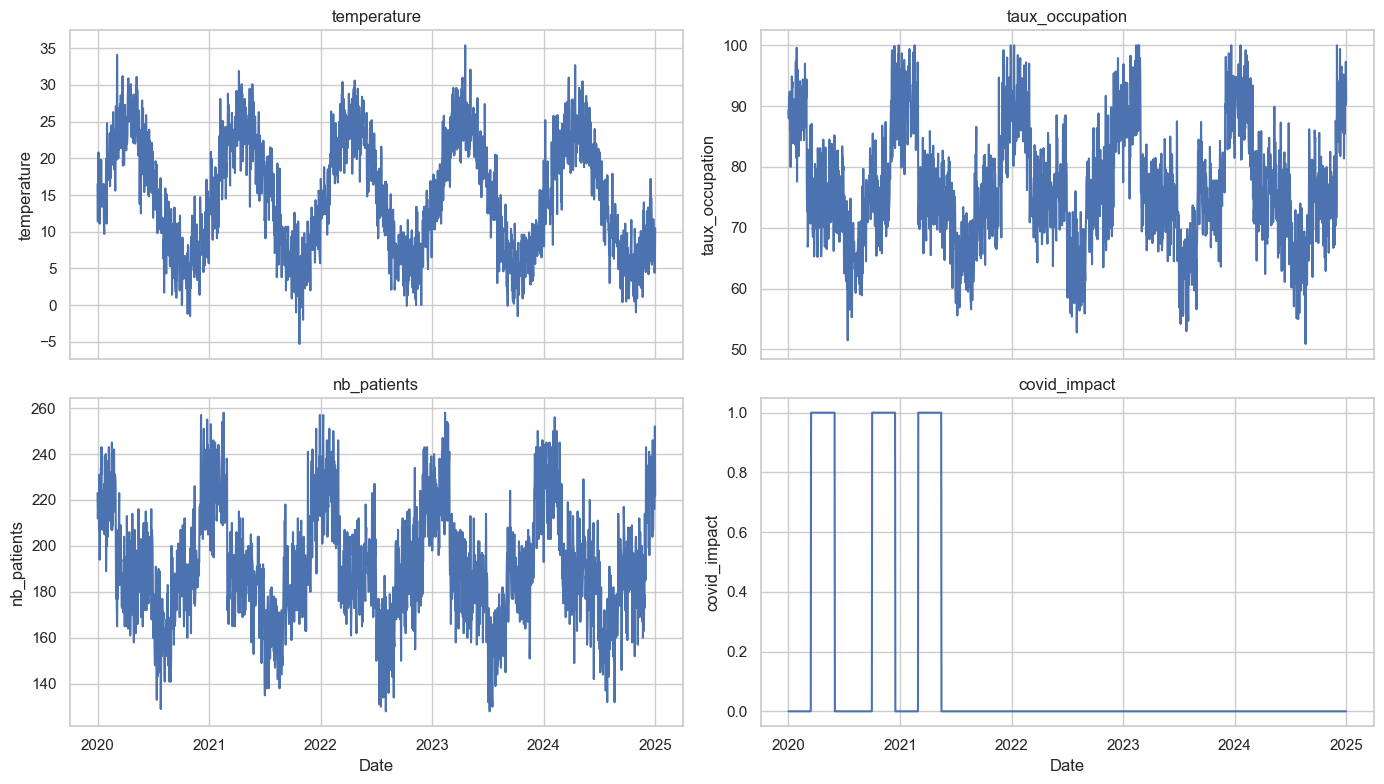

In [46]:
daily_regressors = (
    df.groupby('date')[regressor_cols].mean(numeric_only=True).reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
plot_cols = ['temperature', 'taux_occupation', 'nb_patients', 'covid_impact']

for ax, column in zip(axes.ravel(), plot_cols):
    sns.lineplot(data=daily_regressors, x='date', y=column, ax=ax)
    ax.set_title(column)
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

,temperature,taux_occupation,nb_patients,epidemie_grippe,vacances_scolaires,jour_ferie,covid_impact,consommation
temperature,1.00,0.05,0.05,0.19,0.08,-0.01,0.17,0.07
taux_occupation,0.05,1.00,0.97,0.24,-0.36,-0.01,-0.03,0.42
nb_patients,0.05,0.97,1.00,0.24,-0.35,-0.01,-0.03,0.40
epidemie_grippe,0.19,0.24,0.24,1.00,-0.07,-0.01,-0.01,0.21
vacances_scolaires,0.08,-0.36,-0.35,-0.07,1.00,0.04,-0.09,-0.34
jour_ferie,-0.01,-0.01,-0.01,-0.01,0.04,1.00,0.01,-0.10
covid_impact,0.17,-0.03,-0.03,-0.01,-0.09,0.01,1.00,0.23
consommation,0.07,0.42,0.40,0.21,-0.34,-0.10,0.23,1.00


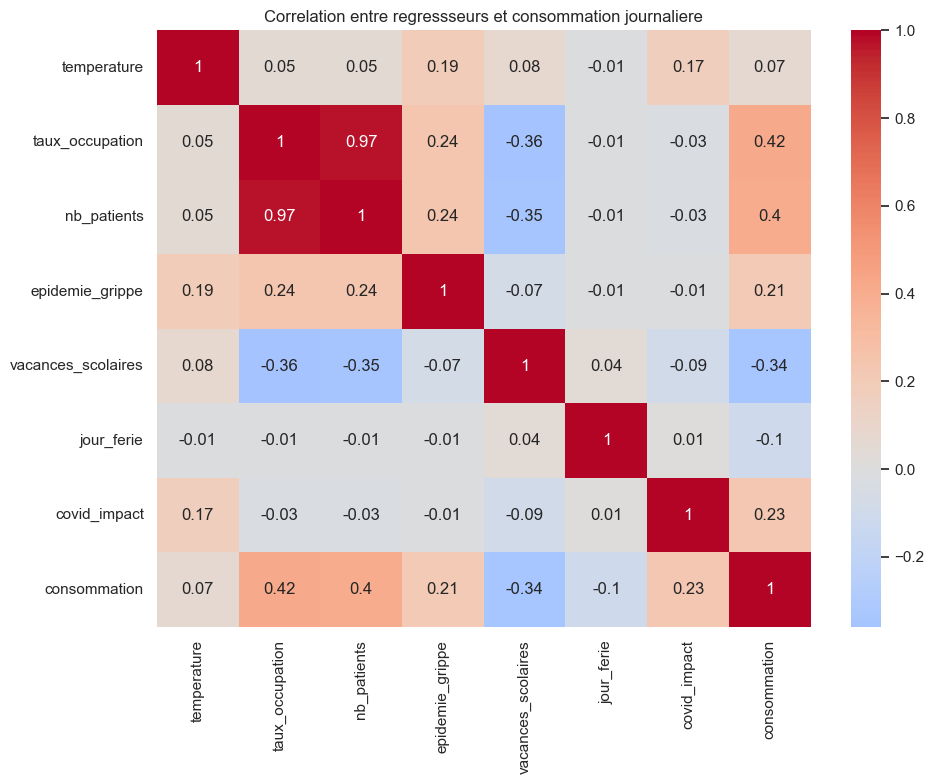

In [47]:
consumption_only = df[df['type_sortie'].eq('CONSOMMATION')].copy()
daily_consumption = consumption_only.groupby('date')['quantite'].sum().rename('consommation').reset_index()
daily_features = daily_regressors.merge(daily_consumption, on='date', how='left').fillna({'consommation': 0})
corr = daily_features.drop(columns='date').corr(numeric_only=True).round(2)
display(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation entre regressseurs et consommation journaliere')
plt.tight_layout()
plt.show()

## 6. Stock et perissabilite

,count,mean,std,min,25%,50%,75%,max
stock_theorique,85809.0,70.25,106.94,0.0,16.9,35.0,84.0,993.31
delai_expiration_jours,85809.0,134.08,201.16,0.0,2.0,11.0,232.0,730.00


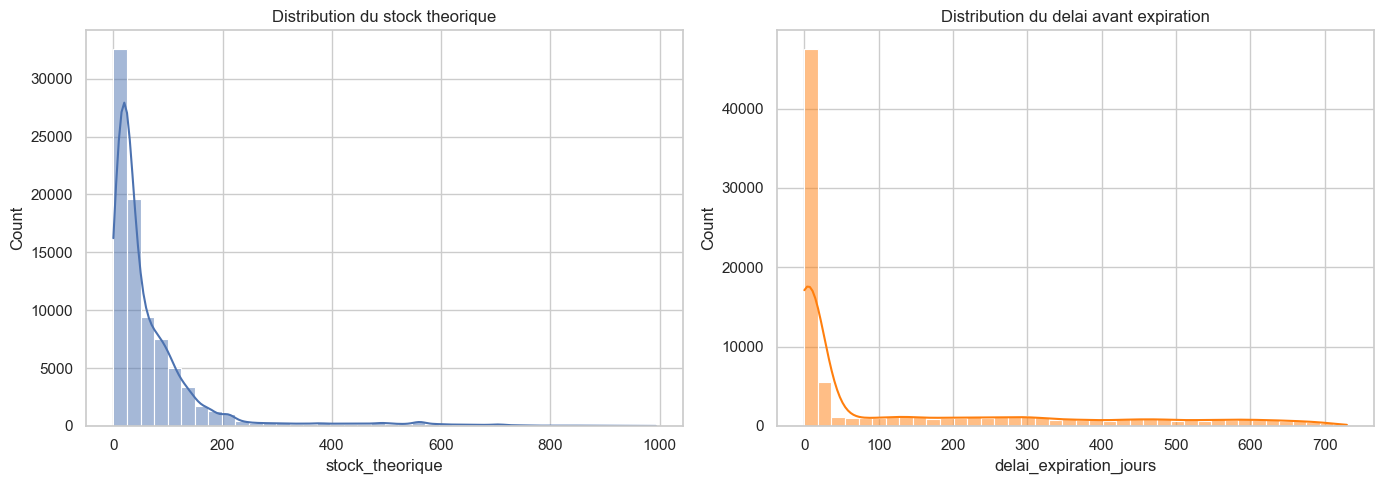

In [48]:
if {'date', 'date_expiration', 'stock_theorique'}.issubset(df.columns):
    df['delai_expiration_jours'] = (df['date_expiration'] - df['date']).dt.days
    stock_summary = df[['stock_theorique', 'delai_expiration_jours']].describe().T.round(2)
    display(stock_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['stock_theorique'].dropna(), bins=40, kde=True, ax=axes[0])
    axes[0].set_title('Distribution du stock theorique')

    sns.histplot(df['delai_expiration_jours'].dropna(), bins=40, kde=True, ax=axes[1], color='tab:orange')
    axes[1].set_title('Distribution du delai avant expiration')

    plt.tight_layout()
    plt.show()
else:
    print('Colonnes insuffisantes pour analyser le stock et la perissabilite.')

## 7. Synthese finale

Ce notebook permet de produire une lecture purement descriptive du dataset enrichi :
- structure et qualite des colonnes
- couverture temporelle
- produits et categories dominants
- volumes de consommation, destruction et entrees
- evolution des regressseurs et corrrelations simples
- indicateurs de stock et de perissabilite

Si besoin, on peut ensuite ajouter un second notebook uniquement pour les analyses metier produit par produit.